# Amazon Product Reviews NLP Project
## Task 1 — Sentiment Analysis

### Goal
The goal of this task is to build a supervised machine-learning model that classifies customer reviews into three sentiment classes:

- **Negative:** ratings 1–2
- **Neutral:** rating 3
- **Positive:** ratings 4–5

The star rating is used only to create the target sentiment label. The model itself learns to predict sentiment from the **review text**.

### Workflow
1. Import libraries
2. Load and inspect the dataset
3. Explore missing values and duplicates
4. Create sentiment labels
5. Explore class distribution
6. Split the data into training and test sets
7. Convert text into TF-IDF features
8. Train a Logistic Regression baseline
9. Evaluate the model
10. Analyze the confusion matrix
11. Test the model on new reviews

## 1. Import Libraries

We first import the libraries required for data manipulation, visualization, text vectorization, model training, and evaluation.

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Make pandas output easier to inspect
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

## 2. Load the Dataset

The project uses the Amazon Product Reviews dataset. We load the CSV file into a pandas DataFrame and inspect its size and first few rows.

> **Note:** Change `DATA_PATH` if the CSV file is stored in another folder or has a different filename.

In [5]:
# Path to the dataset
DATA_PATH = "1429_1.csv"

# Load the CSV file
df = pd.read_csv(DATA_PATH)

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst five rows:")
display(df.head())

Dataset shape: (34660, 21)

First five rows:


/tmp/ipykernel_9416/3915318553.py:5: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfireh...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&p...",This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfireh...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&p...",great for beginner or experienced person. Bought as a gift and she loves it,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfireh...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&p...","Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already...",Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfireh...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,4.0,"http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&page=200,http://reviews.bestbuy.com/3545/5620406/reviews.htm?format=embedded&p...",I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love ...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Computers & Tablets","841667104676,amazon/53004484,amazon/b01ahb9cn2,0841667104676,allnewfirehd8tablet8hddisplaywifi16gbincludesspecialoffersmagenta/5620406,allnewfireh...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,"http://reviews.bestbuy.

## 3. Inspect the Dataset

Before preprocessing, it is important to understand the available columns, their data types, and the amount of missing data.

In [6]:
# Display all column names
print("Columns in the dataset:")
for column in df.columns:
    print("-", column)

Columns in the dataset:
- id
- name
- asins
- brand
- categories
- keys
- manufacturer
- reviews.date
- reviews.dateAdded
- reviews.dateSeen
- reviews.didPurchase
- reviews.doRecommend
- reviews.id
- reviews.numHelpful
- reviews.rating
- reviews.sourceURLs
- reviews.text
- reviews.title
- reviews.userCity
- reviews.userProvince
- reviews.username


In [7]:
# Show concise information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating        34627 non-null  float64
 15  reviews.sourceURLs 

### Columns Used for Sentiment Analysis

For this task we need:

- `reviews.text` — the review text used as the model input.
- `reviews.rating` — the star rating used to generate the sentiment target.

In [8]:
# Keep only the columns needed for Task 1

sentiment_df = df[["reviews.rating"]].copy()
sentiment_df["reviews"] = df["reviews.text"] + " " + df["reviews.title"]

display(sentiment_df.head())

,reviews.rating,reviews
0,5.0,This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease. Ki...
1,5.0,great for beginner or experienced person. Bought as a gift and she loves it very fast
2,5.0,"Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already... Beginner table..."
3,4.0,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love ...
4,5.0,"I bought this for my grand daughter when she comes over to visit. I set it up with her as the user, entered her age and name and now Amazon makes ..."


## 4. Data Quality Checks

We check missing values and duplicate review texts before training the model. Rows without review text or rating cannot be used for supervised sentiment classification.

In [9]:
# Count missing values
print("Missing values:")
print(sentiment_df.isnull().sum())

Missing values:
reviews.rating    33
reviews            7
dtype: int64


In [10]:
# Remove rows where either review text or rating is missing
sentiment_df = sentiment_df.dropna(
    subset=["reviews", "reviews.rating"]
).copy()

print("Shape after removing missing values:", sentiment_df.shape)

Shape after removing missing values: (34620, 2)


In [11]:
# Count duplicate review texts
duplicate_count = sentiment_df["reviews"].duplicated().sum()

print("Number of duplicate review texts:", duplicate_count)

Number of duplicate review texts: 0


In [12]:
# Remove duplicate review texts to reduce repeated samples
sentiment_df = sentiment_df.drop_duplicates(
    subset=["reviews"]
).copy()

print("Shape after removing duplicate reviews:", sentiment_df.shape)

Shape after removing duplicate reviews: (34620, 2)


## 5. Create Sentiment Labels

The project defines the following mapping:

| Star Rating | Sentiment |
|---|---|
| 1–2 | Negative |
| 3 | Neutral |
| 4–5 | Positive |

We create a new `sentiment` column using this mapping.

In [13]:
def rating_to_sentiment(rating):
    """Convert an Amazon star rating into a sentiment class."""

    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"


# Apply the mapping to every rating
sentiment_df["sentiment"] = sentiment_df["reviews.rating"].apply(
    rating_to_sentiment
)

# Inspect the resulting labels
display(
    sentiment_df[
        ["reviews", "reviews.rating", "sentiment"]
    ].head(10)
)

,reviews,reviews.rating,sentiment
0,This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease. Ki...,5.0,positive
1,great for beginner or experienced person. Bought as a gift and she loves it very fast,5.0,positive
2,"Inexpensive tablet for him to use and learn on, step up from the NABI. He was thrilled with it, learn how to Skype on it already... Beginner table...",5.0,positive
3,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great value.We are Prime Members and that is where this tablet SHINES. I love ...,4.0,positive
4,"I bought this for my grand daughter when she comes over to visit. I set it up with her as the user, entered her age and name and now Amazon makes ...",5.0,positive
5,This amazon fire 8 inch tablet is the perfect size. I purchased it for my husband so that he has a bigger screen than just his phone. He had gotte...,5.0,positive
6,"Great for e-reading on the go, nice and light weight, and for the price point given, definitely worth the purchase. great e-reader tablet",4.0,positive
7,"I gave this as a Christmas gift to my inlaws, husband and uncle. They loved it and how easy they are to use with fantastic features! Great for gifts",5.0,positive
8,Great as a device to read books. I like that it links with my borrowed library e-books. Switched from another popular tablet brand and I am happy ...,5.0,positive
9,I love ordering books and reading them with the reader. Great and lightweight reader,5.0,positive


## 6. Exploratory Data Analysis — Class Distribution

Class distribution is particularly important for this dataset because Amazon reviews may contain many more positive reviews than neutral or negative ones.

A model can achieve high accuracy simply by favoring the majority class, so later we will inspect **precision, recall, F1-score, and the confusion matrix**, not accuracy alone.

In [14]:
# Number of samples in each sentiment class
class_counts = sentiment_df["sentiment"].value_counts()

print("Class counts:")
print(class_counts)

# Percentage distribution
class_percentages = (
    sentiment_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nClass percentages:")
print(class_percentages)

Class counts:
sentiment
positive    32309
neutral      1499
negative      812
Name: count, dtype: int64

Class percentages:
sentiment
positive    93.32
neutral      4.33
negative     2.35
Name: proportion, dtype: float64


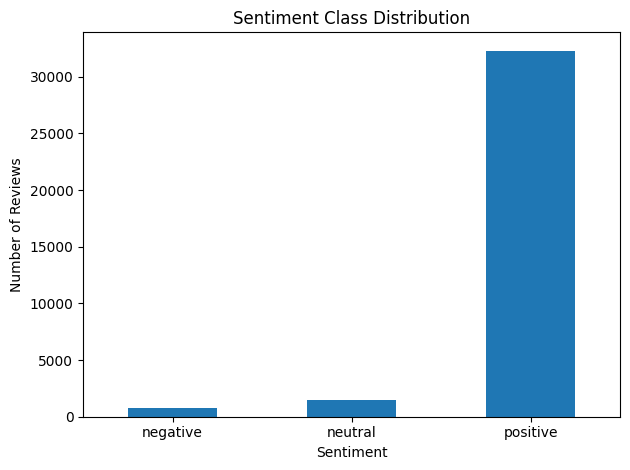

In [15]:
# Visualize sentiment distribution
class_counts.reindex(
    ["negative", "neutral", "positive"]
).plot(kind="bar")

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Define Features and Target

`X` contains the review text and `y` contains the sentiment class that the model must predict.

In [16]:
# Input feature: review text
X = sentiment_df["reviews"]

# Target: sentiment label
y = sentiment_df["sentiment"]

print("Number of reviews:", len(X))
print("\nTarget distribution:")
print(y.value_counts())

Number of reviews: 34620

Target distribution:
sentiment
positive    32309
neutral      1499
negative      812
Name: count, dtype: int64


## 8. Train / Validation / Test Split

For model development we use three separate datasets:

- **Training set (70%)** — used to learn model parameters.
- **Validation set (15%)** — used to compare settings and monitor the transformer during fine-tuning.
- **Test set (15%)** — kept untouched until final evaluation.

We use `stratify=y` in both splits so that the class distribution is approximately preserved.

In [17]:
# Splitting the dataset to train, validation and test

X_train, X_dummy, y_train, y_dummy = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_dummy,
    y_dummy,
    test_size=0.30,
    random_state=42,
    stratify=y_dummy
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True).round(4))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training samples: 24234
Validation samples: 7270
Test samples: 3116

Training distribution:
sentiment
positive    0.9332
neutral     0.0433
negative    0.0235
Name: proportion, dtype: float64

Validation distribution:
sentiment
positive    0.9333
neutral     0.0433
negative    0.0234
Name: proportion, dtype: float64

Test distribution:
sentiment
positive    0.9332
neutral     0.0433
negative    0.0234
Name: proportion, dtype: float64


## 9. TF-IDF Feature Extraction

The traditional baseline converts review text into numerical TF-IDF features.

The vectorizer is fitted **only on the training set**. Validation and test data are transformed using the vocabulary learned from training data, which avoids data leakage.

In [18]:
tfidf = TfidfVectorizer(
    max_features=50000,
    sublinear_tf=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)
# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation and test data
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (24234, 44498)
Validation TF-IDF shape: (7270, 44498)
Test TF-IDF shape: (3116, 44498)


## 10. Baseline Model — Logistic Regression

Logistic Regression provides a strong traditional NLP baseline.

`class_weight="balanced"` is used because the sentiment classes are imbalanced.

In [19]:
logreg_model = LogisticRegression(
    max_iter=1000,
    C=20,
    class_weight="balanced",
    random_state=42
)

logreg_model.fit(X_train_tfidf, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


## 11. Validate the Logistic Regression Model

The validation set gives us an estimate of model performance during development without touching the final test set.

In [20]:
val_pred_logreg = logreg_model.predict(X_val_tfidf)

val_accuracy_logreg = accuracy_score(y_val, val_pred_logreg)

print(f"Validation Accuracy: {val_accuracy_logreg:.4f}\n")

print(
    classification_report(
        y_val,
        val_pred_logreg,
        labels=["negative", "neutral", "positive"],
        digits=4,
        zero_division=0
    )
)

Validation Accuracy: 0.9252

              precision    recall  f1-score   support

    negative     0.4941    0.4941    0.4941       170
     neutral     0.2953    0.2794    0.2871       315
    positive     0.9635    0.9660    0.9647      6785

    accuracy                         0.9252      7270
   macro avg     0.5843    0.5798    0.5820      7270
weighted avg     0.9236    0.9252    0.9244      7270



## 12. Final Logistic Regression Test Evaluation

After model development, we evaluate the baseline on the held-out test set.

In [21]:
test_pred_logreg = logreg_model.predict(X_test_tfidf)

test_accuracy_logreg = accuracy_score(y_test, test_pred_logreg)

print(f"Test Accuracy: {test_accuracy_logreg:.4f}")
print(f"Test Accuracy Percentage: {test_accuracy_logreg * 100:.2f}%\n")

print(
    classification_report(
        y_test,
        test_pred_logreg,
        labels=["negative", "neutral", "positive"],
        digits=4,
        zero_division=0
    )
)

Test Accuracy: 0.9300
Test Accuracy Percentage: 93.00%

              precision    recall  f1-score   support

    negative     0.4750    0.5205    0.4967        73
     neutral     0.3561    0.3481    0.3521       135
    positive     0.9687    0.9673    0.9680      2908

    accuracy                         0.9300      3116
   macro avg     0.5999    0.6120    0.6056      3116
weighted avg     0.9306    0.9300    0.9303      3116



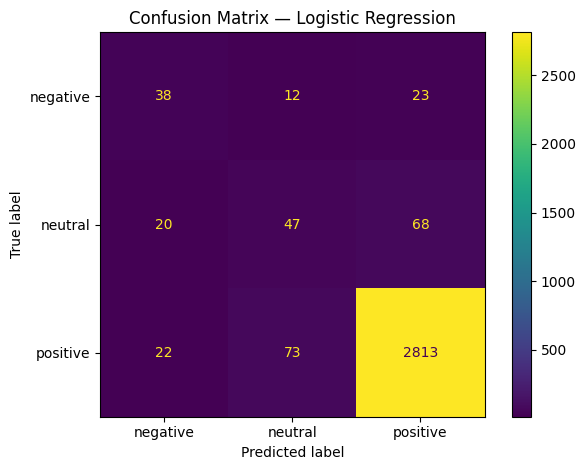

In [22]:
labels = ["negative", "neutral", "positive"]

cm_logreg = confusion_matrix(
    y_test,
    test_pred_logreg,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg,
    display_labels=labels
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

# Part 2 — Fine-Tuning CardiffNLP Twitter-RoBERTa

We now fine-tune the pretrained model:

`cardiffnlp/twitter-roberta-base-sentiment-latest`

The model already has three sentiment classes:

- 0 → Negative
- 1 → Neutral
- 2 → Positive

However, the pretrained model was developed using Twitter data. Fine-tuning it on the Amazon review training set adapts its representations to the product-review domain.

> **Recommended environment:** Google Colab or another machine with a GPU. Transformer fine-tuning on CPU can be very slow.

## 13. Install Transformer Dependencies

Run this cell once if the required Hugging Face libraries are not installed.

After installing packages in Google Colab, you may need to restart the runtime if prompted.

In [23]:
# Uncomment and run if these packages are not installed.
# In Google Colab, this command can be run directly.

# !pip install -q -U transformers datasets accelerate evaluate

## 14. Import Transformer Libraries and Detect the Device

In [24]:
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import precision_recall_fscore_support

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU detected. The notebook will still work, "
        "but fine-tuning RoBERTa may be slow."
    )

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


## 15. Define the RoBERTa Model and Label Mapping

We explicitly define the same label order used by the pretrained CardiffNLP model.

In [25]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

import os
os.environ['HF_TOKEN'] = 'HF_TOKEN'

print("Tokenizer loaded:", MODEL_NAME)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Tokenizer loaded: cardiffnlp/twitter-roberta-base-sentiment-latest


## 16. Build Hugging Face Datasets

The existing train/validation/test split is reused so that Logistic Regression and RoBERTa are evaluated on exactly the same examples.

The text labels are converted into integer IDs because transformer classification models expect numerical targets.

In [26]:
def build_hf_dataset(texts, labels):
    # Reset indices so text and labels align cleanly
    frame = pd.DataFrame({
        "text": texts.reset_index(drop=True),
        "labels": labels.reset_index(drop=True).map(label2id)
    })

    return Dataset.from_pandas(
        frame,
        preserve_index=False
    )


train_dataset = build_hf_dataset(X_train, y_train)
val_dataset = build_hf_dataset(X_val, y_val)
test_dataset = build_hf_dataset(X_test, y_test)

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'labels'],
    num_rows: 24234
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 7270
})
Dataset({
    features: ['text', 'labels'],
    num_rows: 3116
})


## 17. Tokenize the Reviews

RoBERTa operates on tokens rather than raw strings.

`truncation=True` ensures that reviews longer than the model's supported input length are truncated. We use a maximum sequence length of **256 tokens** as a practical balance between review context, GPU memory, and training speed.

In [27]:
MAX_LENGTH = 256

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )


tokenized_train = train_dataset.map(
    tokenize_batch,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_batch,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_batch,
    batched=True
)

# Dynamic padding pads each batch only as much as needed
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print(tokenized_train)

Map:   0%|          | 0/24234 [00:00<?, ? examples/s]

Map:   0%|          | 0/7270 [00:00<?, ? examples/s]

Map:   0%|          | 0/3116 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 24234
})


## 18. Define Evaluation Metrics

Because the dataset is imbalanced, we calculate:

- Accuracy
- Macro precision
- Macro recall
- **Macro F1**

Macro F1 gives equal importance to Negative, Neutral, and Positive classes and is therefore a useful metric for model selection.

In [28]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

## 19. Load the Pretrained RoBERTa Classifier

The pretrained classification head already contains three sentiment outputs. We preserve the three-class structure while explicitly attaching our label names.

In [29]:
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.


## 20. Configure Fine-Tuning

Important settings:

- **Learning rate:** `2e-5`, a common small learning rate for transformer fine-tuning.
- **Epochs:** up to 3.
- **Weight decay:** helps regularization.
- **Validation every epoch:** lets us monitor generalization.
- **Best model:** selected using validation **Macro F1**.
- **Early stopping:** stops training if validation Macro F1 does not improve.

If GPU memory is limited, reduce `per_device_train_batch_size` from 16 to 8.

In [30]:
training_args = TrainingArguments(
    output_dir="./roberta_amazon_sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=42,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=roberta_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ]
)

print("Trainer configured.")

Trainer configured.


## 21. Fine-Tune RoBERTa

This is the computationally expensive step.

The training set updates the model parameters, while the validation set is used to evaluate each epoch and retain the checkpoint with the best validation Macro F1.

In [31]:
train_result = trainer.train()

print("Fine-tuning completed.")

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.154285,0.160805,0.953783,0.718226,0.669205,0.678753
2,0.114819,0.215775,0.951169,0.705510,0.636250,0.658125


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning completed.


## 22. Evaluate the Best Model on the Validation Set

The trainer automatically reloads the checkpoint with the best validation Macro F1 because `load_best_model_at_end=True`.

In [32]:
validation_metrics = trainer.evaluate(
    eval_dataset=tokenized_val
)

validation_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.114819,0.160805,2,0.953783,0.718226,0.669205,0.678753


{'eval_loss': 0.16080540418624878,
 'eval_accuracy': 0.9537826685006877,
 'eval_precision_macro': 0.7182263819919376,
 'eval_recall_macro': 0.6692049684853881,
 'eval_f1_macro': 0.6787529745193979}

## 23. Final RoBERTa Evaluation on the Test Set

The test set has not been used for training or model selection. We now use it once for final performance reporting.

In [33]:
test_output = trainer.predict(
    tokenized_test
)

roberta_test_ids = np.argmax(
    test_output.predictions,
    axis=-1
)

roberta_test_predictions = [
    id2label[int(prediction)]
    for prediction in roberta_test_ids
]

print("RoBERTa Test Metrics:")
print(test_output.metrics)

RoBERTa Test Metrics:
{'test_loss': 0.15368887782096863, 'test_accuracy': 0.9560333761232349, 'test_precision_macro': 0.7489907880068062, 'test_recall_macro': 0.6935866022479553, 'test_f1_macro': 0.6955009114409659, 'test_runtime': 6.7838, 'test_samples_per_second': 459.328, 'test_steps_per_second': 14.446}


In [34]:
print(
    classification_report(
        y_test,
        roberta_test_predictions,
        labels=["negative", "neutral", "positive"],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative     0.6413    0.8082    0.7152        73
     neutral     0.6333    0.2815    0.3897       135
    positive     0.9723    0.9911    0.9816      2908

    accuracy                         0.9560      3116
   macro avg     0.7490    0.6936    0.6955      3116
weighted avg     0.9499    0.9560    0.9497      3116



## 24. RoBERTa Confusion Matrix

This makes it easier to inspect which sentiment classes are confused with each other.

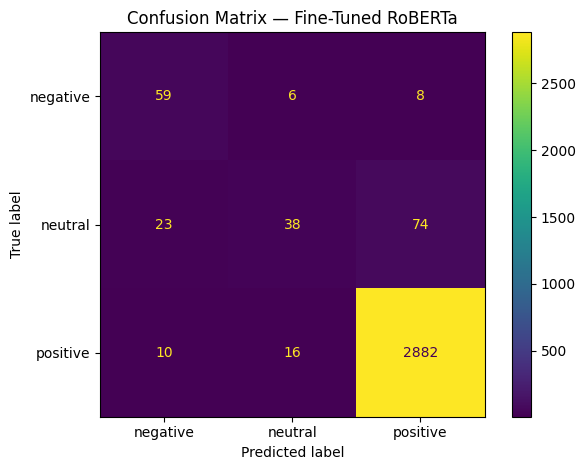

In [35]:
cm_roberta = confusion_matrix(
    y_test,
    roberta_test_predictions,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_roberta,
    display_labels=labels
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Fine-Tuned RoBERTa")
plt.tight_layout()
plt.show()

## 25. Compare Logistic Regression and Fine-Tuned RoBERTa

We compare both models on the **same held-out test set**.

Macro F1 is included because the sentiment classes are imbalanced.

In [36]:
def calculate_summary_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    }


logreg_metrics = calculate_summary_metrics(
    y_test,
    test_pred_logreg
)

roberta_metrics = calculate_summary_metrics(
    y_test,
    roberta_test_predictions
)

comparison_df = pd.DataFrame(
    [
        {
            "Model": "TF-IDF + Logistic Regression",
            **logreg_metrics
        },
        {
            "Model": "Fine-Tuned CardiffNLP RoBERTa",
            **roberta_metrics
        }
    ]
)

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF + Logistic Regression,0.9300,0.5999,0.6120,0.6056
1,Fine-Tuned CardiffNLP RoBERTa,0.9560,0.7490,0.6936,0.6955


## 26. Predict Sentiment for a New Review with Fine-Tuned RoBERTa

This helper function performs inference using the fine-tuned transformer and returns the predicted class together with probabilities for all three sentiment classes.

In [37]:
def predict_roberta_sentiment(review):
    # Tokenize the new review
    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )

    # Move tensors to the same device as the model
    device = trainer.model.device
    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    trainer.model.eval()

    with torch.no_grad():
        outputs = trainer.model(**inputs)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        )[0].cpu().numpy()

    predicted_id = int(np.argmax(probabilities))
    predicted_label = id2label[predicted_id]

    print("Review:")
    print(review)
    print("\nPredicted sentiment:", predicted_label)
    print("\nProbabilities:")

    for class_id in range(3):
        print(
            f"{id2label[class_id]:8s}: "
            f"{probabilities[class_id] * 100:.2f}%"
        )

    return predicted_label

In [38]:
predict_roberta_sentiment(
    "The product works very well and the battery life is excellent."
)

predict_roberta_sentiment(
    "too excellent"
)


Review:
The product works very well and the battery life is excellent.

Predicted sentiment: positive

Probabilities:
negative: 0.03%
neutral : 0.29%
positive: 99.69%
Review:
too excellent

Predicted sentiment: positive

Probabilities:
negative: 0.06%
neutral : 0.44%
positive: 99.50%


'positive'

## 27. Save the Fine-Tuned Model

Saving both the model and tokenizer allows the trained classifier to be reused later for deployment with Gradio or Hugging Face Spaces.

In [39]:
SAVE_PATH = "models/amazon_roberta_sentiment_model"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Fine-tuned model saved to:", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved to: models/amazon_roberta_sentiment_model


# Final Task 1 Summary

This notebook now compares two sentiment-analysis approaches using the same **train / validation / test** split:

### Model 1 — Traditional NLP Baseline
**TF-IDF + Logistic Regression**

Advantages:
- Fast to train.
- Easy to interpret.
- Low computational requirements.
- Strong baseline for text classification.

### Model 2 — Pretrained Transformer
**CardiffNLP Twitter-RoBERTa fine-tuned on Amazon reviews**

Advantages:
- Uses pretrained contextual language representations.
- Can understand word context better than bag-of-words methods.
- Fine-tuning adapts the pretrained Twitter sentiment model to Amazon product reviews.

### Recommended Reporting

For the final project report, include:

1. Train/validation/test methodology.
2. Class distribution and imbalance discussion.
3. Logistic Regression validation and test results.
4. RoBERTa validation and test results.
5. Precision, recall and F1-score for each sentiment class.
6. Both confusion matrices.
7. The final model-comparison table.
8. A discussion of whether fine-tuning RoBERTa improved Macro F1, especially for the minority Negative and Neutral classes.

The held-out **test set should be treated as the final unbiased evaluation** and should not be used to tune model settings.